# Spacecraft Telemetry Anomaly Detection

This notebook builds a baseline anomaly detection model using the NASA SMAP/MSL telemetry dataset.

Workflow:
1. Load labeled anomalies metadata
2. Load train/test telemetry for one channel
3. Create ground-truth anomaly labels
4. Train an Isolation Forest model
5. Evaluate precision, recall, and F1
6. Run a contamination sweep
7. Log experiments with MLflow

## 1. Imports

In [1]:
import ast
from pathlib import Path

import joblib
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

/Users/danntheking/spacecraft-anomaly-detection/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 2. Set Project Paths

Update `PROJECT_ROOT` if your folder path is different.

In [14]:
PROJECT_ROOT = Path("/Users/danntheking/spacecraft-anomaly-detection")

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "archive"
TRAIN_DIR = DATA_DIR / "data" / "data" / "train"
TEST_DIR = DATA_DIR / "data" / "data" / "test"
LABELS_PATH = DATA_DIR / "labeled_anomalies.csv"
MLRUNS_DIR = PROJECT_ROOT / "mlruns"
MODELS_DIR = PROJECT_ROOT / "models"

MODELS_DIR.mkdir(exist_ok=True)
MLRUNS_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data dir exists:", DATA_DIR.exists())
print("Labels path exists:", LABELS_PATH.exists())

Project root: /Users/danntheking/spacecraft-anomaly-detection
Data dir exists: True
Labels path exists: True


## 3. Load Labels Metadata

In [15]:
labels = pd.read_csv(LABELS_PATH)

print(labels.head())
print(labels.columns)
print(labels.shape)

  chan_id spacecraft                           anomaly_sequences  \
0     P-1       SMAP  [[2149, 2349], [4536, 4844], [3539, 3779]]   
1     S-1       SMAP                              [[5300, 5747]]   
2     E-1       SMAP                [[5000, 5030], [5610, 6086]]   
3     E-2       SMAP                              [[5598, 6995]]   
4     E-3       SMAP                              [[5094, 8306]]   

                                  class  num_values  
0  [contextual, contextual, contextual]        8505  
1                               [point]        7331  
2              [contextual, contextual]        8516  
3                               [point]        8532  
4                               [point]        8307  
Index(['chan_id', 'spacecraft', 'anomaly_sequences', 'class', 'num_values'], dtype='object')
(82, 5)


## 4. Select a Telemetry Channel

We will start with `P-1`, a SMAP telemetry channel.

In [16]:
CHANNEL_ID = "P-1"

channel_info = labels[labels["chan_id"] == CHANNEL_ID].iloc[0]

print(channel_info)

chan_id                                                     P-1
spacecraft                                                 SMAP
anomaly_sequences    [[2149, 2349], [4536, 4844], [3539, 3779]]
class                      [contextual, contextual, contextual]
num_values                                                 8505
Name: 0, dtype: object


## 5. Load Train and Test Telemetry

The training data is mostly normal telemetry.  
The test data contains both normal and anomalous behavior.

In [17]:
train_channel = np.load(TRAIN_DIR / f"{CHANNEL_ID}.npy")
test_channel = np.load(TEST_DIR / f"{CHANNEL_ID}.npy")

print("Train shape:", train_channel.shape)
print("Test shape:", test_channel.shape)
print("Test dtype:", test_channel.dtype)
print("First test row:", test_channel[0])

Train shape: (2872, 25)
Test shape: (8505, 25)
Test dtype: float64
First test row: [-0.69516194  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.        ]


## 6. Create Ground-Truth Anomaly Labels

`anomaly_sequences` contains start/end index ranges for anomalous behavior.

In [18]:
y_true = np.zeros(len(test_channel))

ranges = ast.literal_eval(channel_info["anomaly_sequences"])

for start, end in ranges:
    y_true[start:end + 1] = 1

print("Anomaly ranges:", ranges)
print("Actual anomalies:", int(y_true.sum()))
print("Normal points:", int(len(y_true) - y_true.sum()))
print("Anomaly rate:", round(y_true.sum() / len(y_true) * 100, 2), "%")

Anomaly ranges: [[2149, 2349], [4536, 4844], [3539, 3779]]
Actual anomalies: 751
Normal points: 7754
Anomaly rate: 8.83 %


## 7. Scale Features

Scaling helps normalize telemetry features before training.

In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(train_channel)
X_test = scaler.transform(test_channel)

print("Scaled train shape:", X_train.shape)
print("Scaled test shape:", X_test.shape)

Scaled train shape: (2872, 25)
Scaled test shape: (8505, 25)


## 8. Train Baseline Isolation Forest

In [20]:
model = IsolationForest(
    contamination=0.05,
    random_state=42
)

model.fit(X_train)

preds = model.predict(X_test)
preds = (preds == -1).astype(int)

precision = precision_score(y_true, preds)
recall = recall_score(y_true, preds)
f1 = f1_score(y_true, preds)

print("Predicted anomalies:", int(preds.sum()))
print("Actual anomalies:", int(y_true.sum()))
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Predicted anomalies: 459
Actual anomalies: 751
Precision: 0.08496732026143791
Recall: 0.05193075898801598
F1: 0.06446280991735537


## 9. Tune Contamination

Higher contamination means the model predicts more anomalies.

In [21]:
results = []

for c in [0.01, 0.02, 0.05, 0.10, 0.15]:
    model = IsolationForest(
        contamination=c,
        random_state=42
    )

    model.fit(X_train)

    preds = model.predict(X_test)
    preds = (preds == -1).astype(int)

    precision = precision_score(y_true, preds)
    recall = recall_score(y_true, preds)
    f1 = f1_score(y_true, preds)

    results.append({
        "contamination": c,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "predicted_anomalies": int(preds.sum()),
        "actual_anomalies": int(y_true.sum())
    })

results_df = pd.DataFrame(results)
results_df

,contamination,precision,recall,f1,predicted_anomalies,actual_anomalies
0,0.01,0.080000,0.010652,0.018801,100,751
1,0.02,0.064706,0.014647,0.023887,170,751
2,0.05,0.084967,0.051931,0.064463,459,751
3,0.10,0.085556,0.102530,0.093277,900,751
4,0.15,0.091528,0.161119,0.116739,1322,751


## 10. Pick Best Model by F1

In [22]:
best_row = results_df.sort_values("f1", ascending=False).iloc[0]
best_contamination = best_row["contamination"]

print("Best contamination:", best_contamination)
print(best_row)

Best contamination: 0.15
contamination             0.150000
precision                 0.091528
recall                    0.161119
f1                        0.116739
predicted_anomalies    1322.000000
actual_anomalies        751.000000
Name: 4, dtype: float64


## 11. Visualize Actual vs Predicted Anomalies

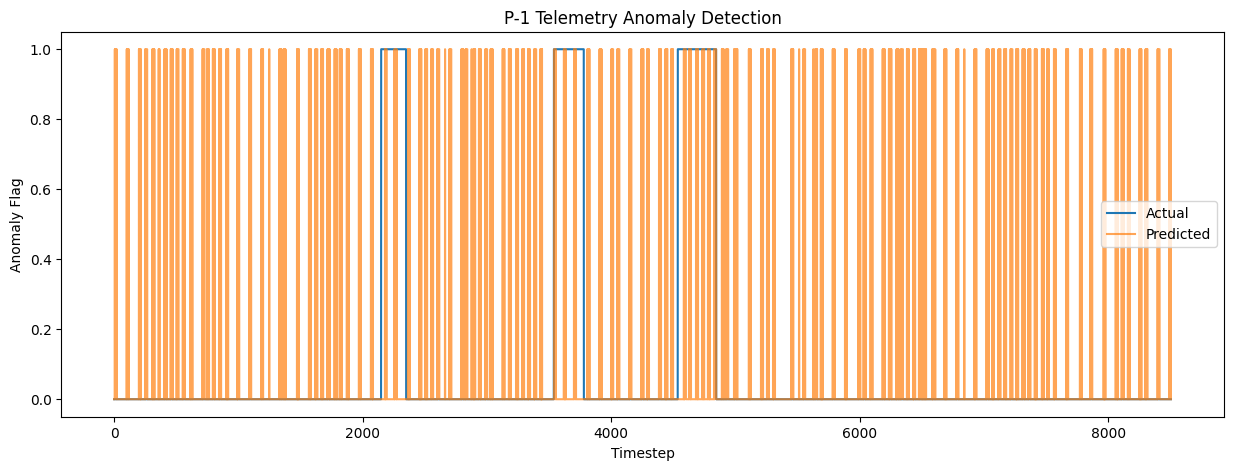

In [23]:
best_model = IsolationForest(
    contamination=float(best_contamination),
    random_state=42
)

best_model.fit(X_train)

best_preds = best_model.predict(X_test)
best_preds = (best_preds == -1).astype(int)

plt.figure(figsize=(15, 5))
plt.plot(y_true, label="Actual")
plt.plot(best_preds, alpha=0.7, label="Predicted")
plt.legend()
plt.title(f"{CHANNEL_ID} Telemetry Anomaly Detection")
plt.xlabel("Timestep")
plt.ylabel("Anomaly Flag")
plt.show()

## 12. Log Experiments with MLflow

Start MLflow UI from your project root with:

```bash
mlflow ui --backend-store-uri "file:///Users/danntheking/spacecraft-anomaly-detection/mlruns"
```

In [ ]:
mlflow.set_tracking_uri(f"file://{MLRUNS_DIR}")
mlflow.set_experiment("spacecraft-anomaly-detection")

for row in results:
    contamination = row["contamination"]

    with mlflow.start_run(run_name=f"isolation_forest_c_{contamination}"):

        model = IsolationForest(
            contamination=contamination,
            random_state=42
        )

        model.fit(X_train)

        preds = model.predict(X_test)
        preds = (preds == -1).astype(int)

        precision = precision_score(y_true, preds)
        recall = recall_score(y_true, preds)
        f1 = f1_score(y_true, preds)

        mlflow.log_param("channel_id", CHANNEL_ID)
        mlflow.log_param("model_type", "IsolationForest")
        mlflow.log_param("contamination", contamination)
        mlflow.log_param("train_rows", X_train.shape[0])
        mlflow.log_param("test_rows", X_test.shape[0])
        mlflow.log_param("features", X_train.shape[1])

        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1", f1)
        mlflow.log_metric("predicted_anomalies", int(preds.sum()))
        mlflow.log_metric("actual_anomalies", int(y_true.sum()))

        mlflow.sklearn.log_model(
            sk_model=model,
            name="isolation_forest_model",
            input_example=X_test[:5]
        )

print("Logged runs to:", mlflow.get_tracking_uri())

## 13. Save Best Model and Scaler Locally

In [ ]:
best_model_path = MODELS_DIR / "isolation_forest_p1.joblib"
scaler_path = MODELS_DIR / "standard_scaler_p1.joblib"

joblib.dump(best_model, best_model_path)
joblib.dump(scaler, scaler_path)

print("Saved model:", best_model_path)
print("Saved scaler:", scaler_path)

## 14. Resume Bullet Draft

Built a spacecraft telemetry anomaly detection pipeline using NASA SMAP/MSL data, Isolation Forest, scikit-learn, and MLflow. Created ground-truth anomaly labels from sequence metadata, tuned anomaly detection thresholds, tracked experiments, and prepared the workflow for Azure Machine Learning deployment.